In [3]:
import matplotlib

matplotlib.rcParams.update({"legend.fontsize": 14, "legend.handlelength": 2})
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.5)
import pandas as pd

/home/albert/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


#### Load `uam_system_model` dependencies

In [5]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import (
    plot_hourly_flight_distribution,
    plot_parameters,
)

#### Prepare input

In [6]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix


import numpy as np
from geopy.distance import geodesic

coordinates = np.array(
    [
        (33.94417072663332, -118.40248449470265),
        (34.043119432990345, -118.26720629762752),
        (33.81606030845284, -118.15122129260827),
        (34.17160155814583, -118.60525790222589),
        (34.13843197335217, -118.35511311047983),
        (33.812102161009804, -117.91897753216998),
        (34.09174681098575, -118.32725521957076),
        (34.08807589928915, -118.55063573741867),
        (34.06666969690935, -118.4114352069469),
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ["LAX", "DTLA", "LGB", "WDHL", "UVS", "ANH", "HWD", "PSD", "BVH"]

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])

# vertiport_pmf = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])

vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "uam_system_model/data/config/energy_consumption_matrix.npy"
)

#### Create instance variable

In [7]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

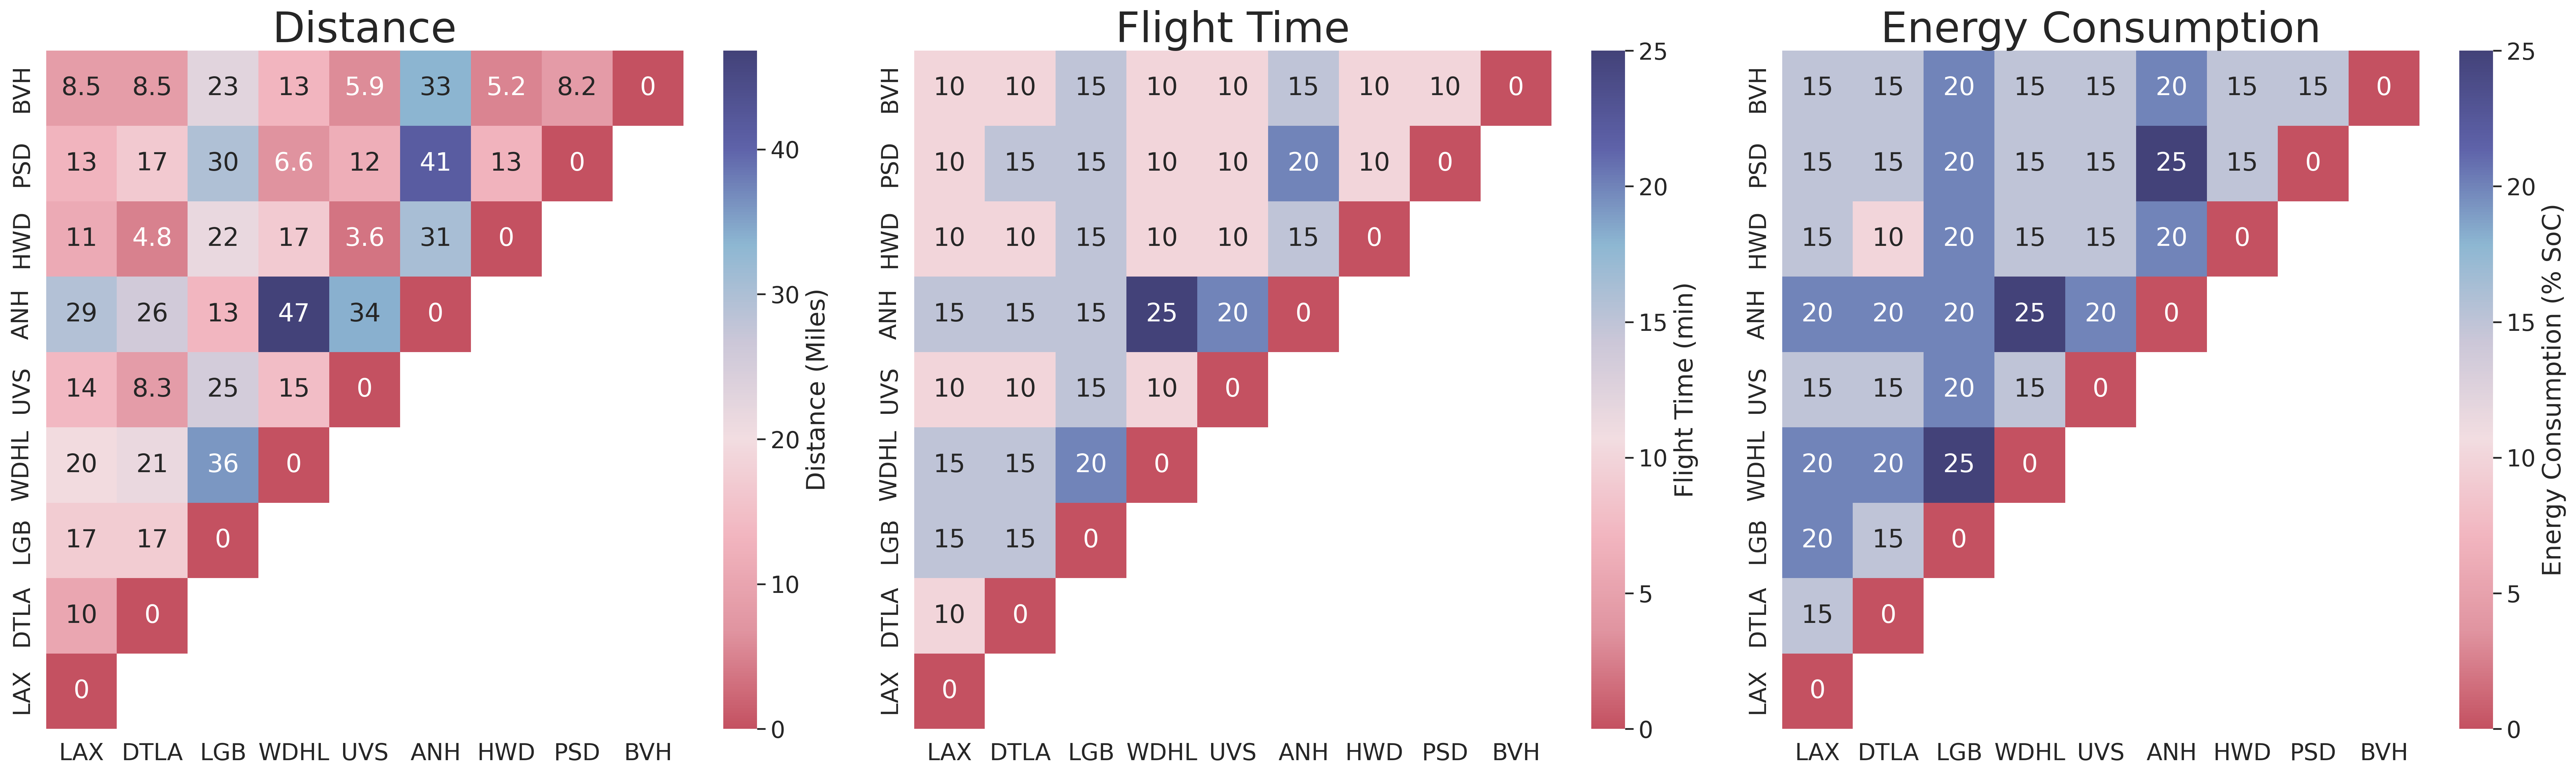

In [9]:
plot_parameters(network);

#### Load demand & visualize

In [8]:
network.load_demand(
    month=8,
    day=1,
    directional_demand=2500,
    vertiport_pmf=vertiport_pmf,
)
network.schedule


,schedule,od,num_pax,revenue
0,5.000000,LAX_UVS,2,82.453401
1,5.332175,LAX_PSD,1,39.422171
2,5.721582,LAX_BVH,1,25.524422
3,5.808741,LAX_LGB,3,153.251632
4,7.487321,LAX_ANH,4,353.024188
...,...,...,...,...
2323,1438.546276,LAX_WDHL,1,58.902360
2324,1438.767864,LAX_PSD,1,39.422171
2325,1438.817763,LAX_UVS,2,82.453401
2326,1439.995479,ANH_LAX,1,88.256047


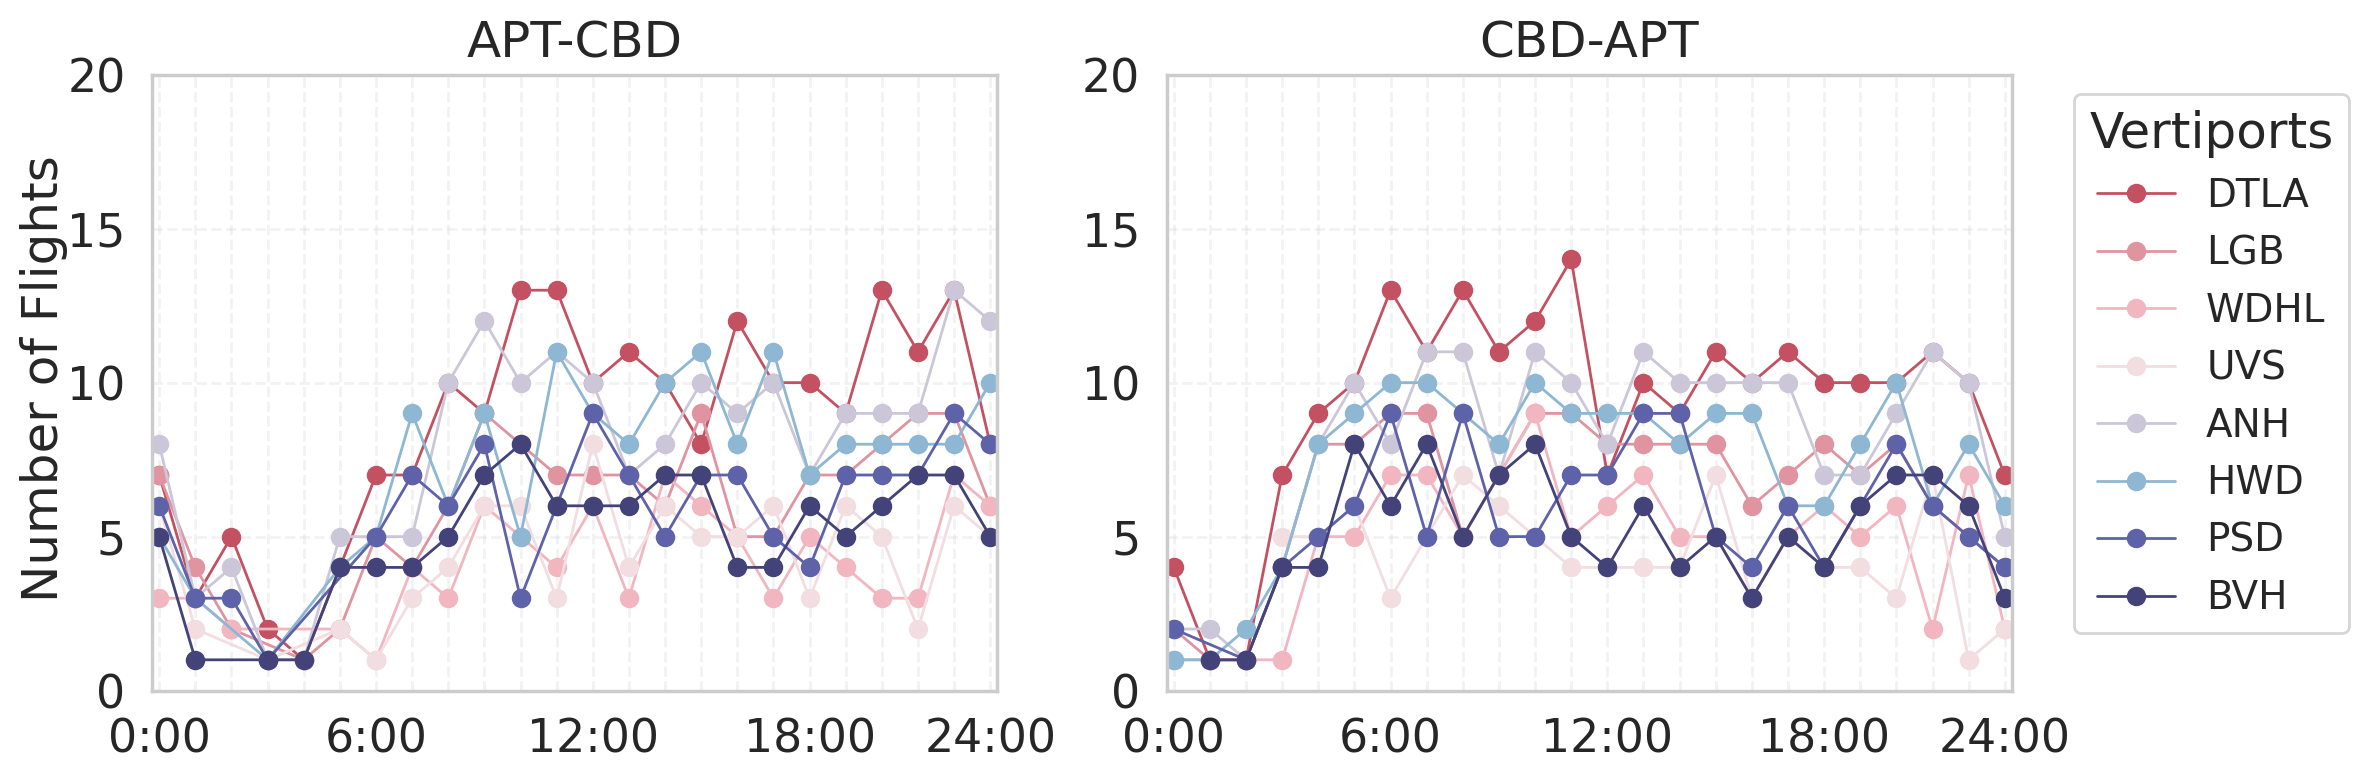

In [9]:
fig, ax = plot_hourly_flight_distribution(network, ylim=(0, 20))
plt.show()

#### Two-vertiport zero-spill (fleet sizing) optimization

In [12]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

In [ ]:
ip = FleetSizeOptimizer(network)
fleetsize, policy = ip.optimize(vertiport_index=4,
                                verbose=True, 
                                optimality_gap=0.05, 
                                n_threads=24)

In [ ]:
summary = FleetSizeOpSummary(network, policy)

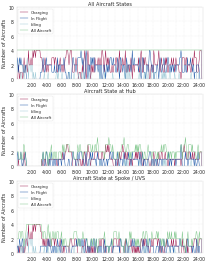

In [138]:
fig, ax = summary.plot_aircraft_state()
for a in ax:
    a.figure.set_dpi(20)

In [140]:
summary.get_summary_statistics()

{'fleet_size': 4,
 'total_pads': 7,
 'pads_at_hub': 3,
 'pads_at_spoke': 4,
 'number_of_flights': 236,
 'number_of_repositioning_flights': 47,
 'percentage_repositioning_flights': 0.1992,
 'energy_consumption_kWh': 5664.0,
 'TAM': 3243.17,
 'RAM': 2597.28}

#### Run VRP Optimization

In [1]:
from uam_system_model.FleetOpVRP import FleetOpVRP
from uam_system_model.utils.FleetOpVRPSummary import FleetOpVRPSummary

In [6]:
vrp = FleetOpVRP(StarNetwork=network)
unserved_tours, served_tours = vrp.optimize(15, 3, 0.7, n_processes=20, verbose=True)

INFO - 2025-07-04 22:49:35,678 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [1] BUILDING SUBTOURS
INFO - 2025-07-04 22:49:38,304 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [2] SOLVING KNAPSACK PROBLEM


Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-30


INFO - 2025-07-04 22:49:38,414 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS BEFORE: 328 NUMBER OF TOURS AFTER: 328
INFO - 2025-07-04 22:49:38,415 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [3] SOLVING THE CLUSTERING/SCHEDULING PROBLEM
100%|██████████| 658/658 [00:02<00:00, 226.36it/s]
INFO - 2025-07-04 22:49:42,205 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF FLIGHTS SELECTED AFTER CLUSTERING: 328/328
INFO - 2025-07-04 22:49:42,208 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [4] SOLVING 1-VRP


TOURS SERVED: 3/3
FLIGHTS SERVED: 3/3
TOURS SERVED: 2/2
FLIGHTS SERVED: 2/2
TOURS SERVED: 7/9
FLIGHTS SERVED: 7/9
TOURS SERVED: 19/21
FLIGHTS SERVED: 19/21
TOURS SERVED: 19/21
FLIGHTS SERVED: 19/21
TOURS SERVED: 27/31
FLIGHTS SERVED: 27/31
TOURS SERVED: 12/14
FLIGHTS SERVED: 12/14
TOURS SERVED: 20/25
FLIGHTS SERVED: 20/25
TOURS SERVED: 27/33
FLIGHTS SERVED: 27/33
TOURS SERVED: 27/33
FLIGHTS SERVED: 27/33
TOURS SERVED: 17/20
FLIGHTS SERVED: 17/20
TOURS SERVED: 20/28
FLIGHTS SERVED: 20/28
TOURS SERVED: 18/22
FLIGHTS SERVED: 18/22
TOURS SERVED: 29/37
FLIGHTS SERVED: 29/37
TOURS SERVED: 24/29
FLIGHTS SERVED: 24/29


INFO - 2025-07-04 23:07:55,919 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF SERVED FLIGHTS: 271 / 328
INFO - 2025-07-04 23:07:55,920 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - [5] Iterative Insertion
INFO - 2025-07-04 23:07:55,921 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - NUMBER OF SERVED FLIGHTS: 271 / 328


TOURS SERVED: 30/60
FLIGHTS SERVED: 30/60
TOURS SERVED: 27/47
FLIGHTS SERVED: 27/47
TOURS SERVED: 25/38
FLIGHTS SERVED: 25/38
TOURS SERVED: 30/40
FLIGHTS SERVED: 30/40
TOURS SERVED: 25/29
FLIGHTS SERVED: 25/29
TOURS SERVED: 27/28
FLIGHTS SERVED: 27/28
TOURS SERVED: 19/20
FLIGHTS SERVED: 19/20
TOURS SERVED: 20/21
FLIGHTS SERVED: 20/21
TOURS SERVED: 30/30
FLIGHTS SERVED: 30/30
TOURS SERVED: 27/27
FLIGHTS SERVED: 27/27
TOURS SERVED: 20/20
FLIGHTS SERVED: 20/20
TOURS SERVED: 27/27
FLIGHTS SERVED: 27/27
TOURS SERVED: 7/7
FLIGHTS SERVED: 7/7


INFO - 2025-07-04 23:20:23,053 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - OPTIMIZATION COMPLETE
INFO - 2025-07-04 23:20:23,054 - FleetOpVRP_M8_D1_V15_MZPT3_MTE7 - TOTAL NUMBER OF SERVED FLIGHTS: 328


TOURS SERVED: 12/12
FLIGHTS SERVED: 12/12
TOURS SERVED: 2/2
FLIGHTS SERVED: 2/2


In [10]:
# The optimization can take a while to solve, attached is a sample solution. The input should be the same as the `served_tours` variable in the previous cell.
served_tours = pd.read_csv("uam_system_model/data/sample_vrp_solution.csv")
summary = FleetOpVRPSummary(
    StarNetwork=network,
    policy=served_tours,
)
summary.get_summary_statistics()

{'fleet_size': 41,
 'total_pads': 73,
 'pads_at_vertiport': {'LAX': 22,
  'DTLA': 11,
  'LGB': 7,
  'WDHL': 6,
  'UVS': 4,
  'ANH': 7,
  'HWD': 7,
  'PSD': 5,
  'BVH': 4},
 'max_takeoff_per_hour': {'LAX': 69,
  'DTLA': 21,
  'LGB': 15,
  'WDHL': 9,
  'UVS': 10,
  'ANH': 16,
  'HWD': 15,
  'PSD': 12,
  'BVH': 11},
 'number_of_aircraft_hours': 420.42,
 'number_of_flights': 2213,
 'number_of_revenue_flights': 1952,
 'number_of_repositioning_flights': 261,
 'percentage_repositioning_flights': 0.1179,
 'energy_consumption_kWh': 37812.5,
 'TAM': 33671.96,
 'RAM': 29986.01,
 'average_load_factor': 0.6036}